## 1. Subscribe to the model package

To subscribe to the model package:
1. Open the model package listing page [DICOM Images De-identification - Alias](https://aws.amazon.com/marketplace/pp/prodview-uqh2xim2fcbxa)
1. On the AWS Marketplace listing, click on the **Continue to subscribe** button.
1. On the **Subscribe to this software** page, review and click on **"Accept Offer"** if you and your organization agrees with EULA, pricing, and support terms.
1. Once you click on **Continue to configuration button** and then choose a **region**, you will see a **Product Arn** displayed. This is the model package ARN that you need to specify while creating a deployable model using Boto3. Copy the ARN corresponding to your region and specify the same in the following cell.

## Dicom deid generic augmented pseudonym


- **Model**: `dicom_deid_generic_augmented_pseudonym`
- **Model Description**:  This pipeline is designed to de-identifying dicom.


In [1]:
model_package_arn = "<Customer to specify Model package ARN corresponding to their AWS region>"

In [ ]:
import base64
import shutil
import json
import os
import uuid
from sagemaker import ModelPackage
import sagemaker as sage
from sagemaker import get_execution_role
import boto3
from IPython.display import Image, display
from PIL import Image as ImageEdit
from urllib.parse import urlparse
import numpy as np
import pydicom
import matplotlib.pyplot as plt


def display_dicom(file_path, title=None):
    ds = pydicom.dcmread(file_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(ds.pixel_array, cmap="gray")
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


def display_comparison(input_path, output_path, title=None):
    input_ds = pydicom.dcmread(input_path)
    output_ds = pydicom.dcmread(output_path)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(input_ds.pixel_array, cmap="gray")
    axes[0].set_title("Before")
    axes[0].axis("off")

    axes[1].imshow(output_ds.pixel_array, cmap="gray")
    axes[1].set_title("De-identified")
    axes[1].axis("off")

    if title:
        fig.suptitle(title)
    plt.show()

In [ ]:
!pip install pydicom

In [17]:
sagemaker_session = sage.Session()
s3_bucket = sagemaker_session.default_bucket()
region = sagemaker_session.boto_region_name
account_id = boto3.client("sts").get_caller_identity().get("Account")
role = get_execution_role()

sagemaker = boto3.client("sagemaker")
s3_client = sagemaker_session.boto_session.client("s3")
ecr = boto3.client("ecr")
sm_runtime = boto3.client("sagemaker-runtime")

In [18]:
model_name = "dicom-deid-generic-augmented-pseudonym"

real_time_inference_instance_type = "ml.m4.xlarge"
batch_transform_inference_instance_type = "ml.m4.2xlarge"

In [19]:
# create a deployable model from the model package.
model = ModelPackage(
    role=role,
    model_package_arn=model_package_arn,
    sagemaker_session=sagemaker_session,
)

## 2. Create an endpoint and perform real-time inference

If you want to understand how real-time inference with Amazon SageMaker works, see [Documentation](https://docs.aws.amazon.com/sagemaker/latest/dg/how-it-works-hosting.html).

In [20]:
# Deploy the model
predictor = model.deploy(
    initial_instance_count=1,
    instance_type=real_time_inference_instance_type,
    endpoint_name=model_name,
)

--------------!

Once endpoint has been created, you would be able to perform real-time inference.

In [21]:
import pandas as pd
import os
import io

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

def process_data_and_invoke_realtime_endpoint(dicom_file, content_type):
    with open(dicom_file, "rb") as file:
        dicom_data = file.read()

    output_file_name = f"outputs/real-time/{os.path.basename(dicom_file)}"
    os.makedirs(os.path.dirname(output_file_name), exist_ok=True)

    response = sm_runtime.invoke_endpoint(
        EndpointName=model_name,
        ContentType=content_type,
        Accept="application/octet-stream",
        Body=dicom_data,
    )

    with io.FileIO(output_file_name, 'w') as file:
        for b in response['Body']._raw_stream:
            file.write(b)

    return output_file_name

### Initial setup

In [ ]:
!wget --no-check-certificate https://github.com/JohnSnowLabs/visual-nlp-workshop/raw/refs/heads/master/jupyter/data/dicom/deidentify-medical-1.dcm -O deidentify-medical-1.dcm
!wget --no-check-certificate https://github.com/JohnSnowLabs/visual-nlp-workshop/raw/refs/heads/master/jupyter/data/dicom/deidentify-medical-2.dcm -O deidentify-medical-2.dcm

### JSON

#### Example 1

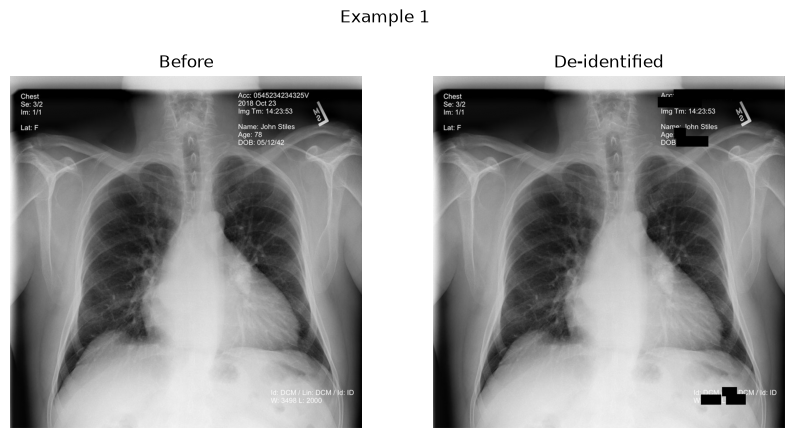

In [ ]:
file_name = process_data_and_invoke_realtime_endpoint(dicom_file='./deidentify-medical-1.dcm', content_type='application/octet-stream')
display_comparison('./deidentify-medical-1.dcm', file_name, title="Example 1")

#### Example 2

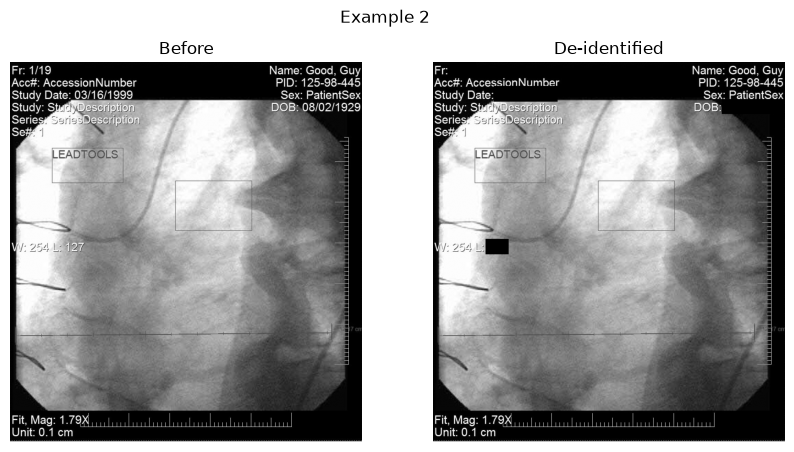

In [ ]:
file_name = process_data_and_invoke_realtime_endpoint(dicom_file='./deidentify-medical-2.dcm', content_type='application/octet-stream')
display_comparison('./deidentify-medical-2.dcm', file_name, title="Example 2")

Now that you have successfully performed a real-time inference, you do not need the endpoint any more. You can terminate the endpoint to avoid being charged.

In [25]:
model.sagemaker_session.delete_endpoint(model_name)
model.sagemaker_session.delete_endpoint_config(model_name)

## 3. Batch inference

In [26]:
validation_file_name1 = "deidentify-medical-1.dcm"
validation_file_name2 = "deidentify-medical-2.dcm"

validation_input_path = f"s3://{s3_bucket}/{model_name}/validation-input/batch"
validation_output_path = f"s3://{s3_bucket}/{model_name}/validation-output/batch"

output_dir = 'outputs/batch'
os.makedirs(output_dir, exist_ok=True)

In [27]:
def upload_dicom_to_s3(local_file_path):
    base_file_name = os.path.basename(local_file_path)
    validation_input_file_path = f"{model_name}/validation-input/batch/{base_file_name}"
    s3_client.upload_file(local_file_path, s3_bucket, validation_input_file_path)

In [28]:
upload_dicom_to_s3(validation_file_name1)
upload_dicom_to_s3(validation_file_name2)

In [ ]:
# Initialize a SageMaker Transformer object for making predictions
transformer = model.transformer(
    instance_count=1,
    instance_type=batch_transform_inference_instance_type,
    accept="application/octet-stream",
    output_path=validation_output_path
)

transformer.transform(validation_input_path, content_type='application/octet-stream')
transformer.wait()

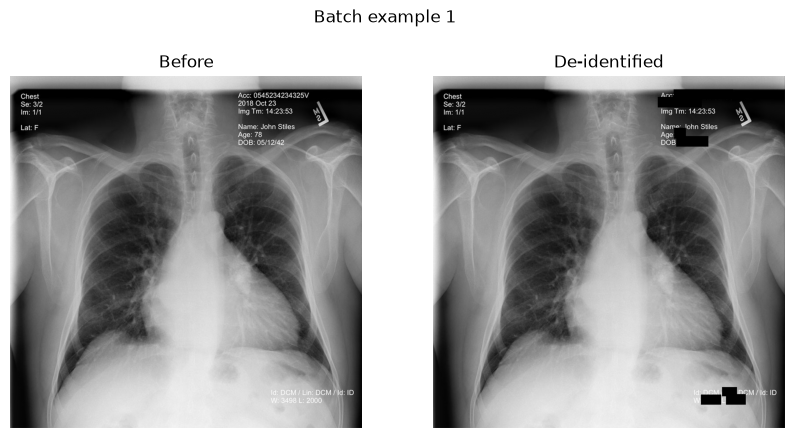

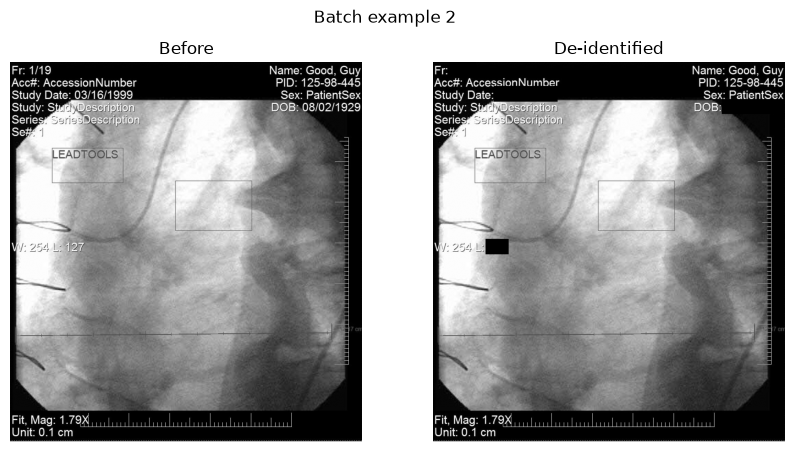

In [ ]:
parsed_url = urlparse(transformer.output_path)

for i, validation_file_name in enumerate([validation_file_name1, validation_file_name2], start=1):
    file_key = f"{parsed_url.path[1:]}/{validation_file_name}.out"
    response = s3_client.get_object(Bucket=s3_bucket, Key=file_key)
    output_file_name = f"{output_dir}/example_out_{i}.dcm"
    with io.FileIO(output_file_name, 'w') as file:
        for b in response['Body']._raw_stream:
            file.write(b)

    display_comparison(validation_file_name, output_file_name, title=f"Batch example {i}")

In [31]:
model.delete_model()

INFO:sagemaker:Deleting model with name: dicom-deid-generic-augmented-pseudonym--2026-08-14-08-21-19-170


### Unsubscribe to the listing (optional)

If you would like to unsubscribe to the model package, follow these steps. Before you cancel the subscription, ensure that you do not have any [deployable model](https://console.aws.amazon.com/sagemaker/home#/models) created from the model package or using the algorithm. Note - You can find this information by looking at the container name associated with the model.

**Steps to unsubscribe to product from AWS Marketplace**:
1. Navigate to __Machine Learning__ tab on [__Your Software subscriptions page__](https://aws.amazon.com/marketplace/ai/library?productType=ml&ref_=mlmp_gitdemo_indust)
2. Locate the listing that you want to cancel the subscription for, and then choose __Cancel Subscription__  to cancel the subscription.
